In [10]:
import os
from pathlib import Path
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

# Load environment variables
load_dotenv(override=True)

True

#### Basic LangGraph flow

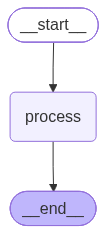

{'messages': 'Hello Vidhan.'}


In [11]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

class State(TypedDict):
    messages: str

def process(state: State):
    return {'messages': state['messages'] + " Vidhan."}

graph = StateGraph(State)

graph.add_node("process", process)
graph.add_edge(START, "process")
graph.add_edge("process", END)

app = graph.compile()
display(Image(app.get_graph().draw_mermaid_png()))

result = app.invoke({"messages": "Hello"})

print(result)



#### Langgraph with OpenAI model

{'query': 'What is the capital of France?', 'answer': 'The capital of France is Paris.'}


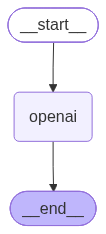

In [14]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from IPython.display import display, Image

## 1. Define graph state
class State(TypedDict):
    query: str
    answer: str

model = ChatOpenAI(model="gpt-4.1-mini", temperature=0, max_tokens=1000, max_retries=3, request_timeout=30)

## 2. Define graph nodes
def process_query(state: State):
    response = model.invoke(state['query'])
    return {'answer': response.content}

## 3. Build graph
builder = StateGraph(State)
builder.add_node('openai', process_query);
builder.add_edge(START, 'openai')
builder.add_edge('openai', END)

### 4. Compile graph
app = builder.compile()

### 5. Invoke graph
result = app.invoke({'query': 'What is the capital of France?', 'answer': ''})

print(result)  # Display the AI's response
display(Image(app.get_graph().draw_mermaid_png()))

#### Conditional Edge

Checking number: 10
{'number': 10, 'result': '10 is even'}


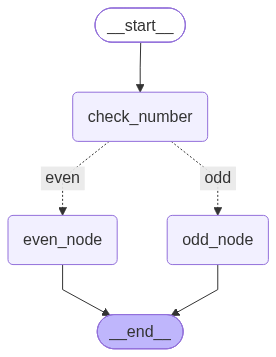

In [16]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

# 1. Define state
class State(TypedDict):
    number: int
    result: str


# 2. Nodes
def check_number(state: State):
    print("Checking number:", state["number"])
    return {}


def even_node(state: State):
    return {
        "result": f"{state['number']} is even"
    }


def odd_node(state: State):
    return {
        "result": f"{state['number']} is odd"
    }


# 3. Routing function
def route_number(state: State):
    if state["number"] % 2 == 0:
        return "even"
    else:
        return "odd"


# 4. Build graph
builder = StateGraph(State)

builder.add_node("check_number", check_number)
builder.add_node("even_node", even_node)
builder.add_node("odd_node", odd_node)

builder.add_edge(START, "check_number")

# Conditional edge
builder.add_conditional_edges(
    "check_number",
    route_number,
    {
        "even": "even_node",
        "odd": "odd_node"
    }
)

builder.add_edge("even_node", END)
builder.add_edge("odd_node", END)


# 5. Compile
graph = builder.compile()


# 6. Run
result = graph.invoke({
    "number": 10,
    "result": ""
})

print(result)
display(Image(graph.get_graph().draw_mermaid_png()))

#### Reducers & MessageState

{'total': 15}


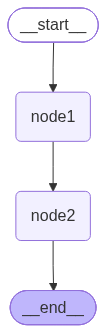

In [17]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image


def add_values(old, new):
    return old + new


class State(TypedDict):
    total: Annotated[int, add_values]


def node1(state):
    return {"total": 5}


def node2(state):
    return {"total": 10}


builder = StateGraph(State)

builder.add_node("node1", node1)
builder.add_node("node2", node2)

builder.add_edge(START, "node1")
builder.add_edge("node1", "node2")
builder.add_edge("node2", END)

graph = builder.compile()

result = graph.invoke({
    "total": 0
})

print(result)
display(Image(graph.get_graph().draw_mermaid_png()))

#### Chatbot with MessageState


USER: My name is Rahul.
AI: Hello Rahul! How can I assist you today?

USER: What is my name?
AI: Your name is Rahul. How can I help you further?

USER: What is LangGraph?
AI: LangGraph is a framework or tool designed to help build applications that leverage large language models (LLMs) by organizing and managing the flow of data and tasks in a graph-like structure. It allows developers to create complex workflows where different components—such as data sources, language model calls, and processing steps—are represented as nodes in a graph. This approach helps in orchestrating interactions with LLMs more efficiently, enabling modularity, reusability, and better control over the execution of language model-based applications.

If you want, I can provide more detailed information or examples of how LangGraph is used!

USER: Why is MessagesState useful?
AI: `MessagesState` is useful because it helps manage and maintain the state of a conversation or a sequence of messages in applications 

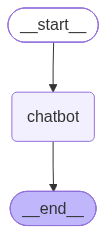

In [20]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from IPython.display import display, Image

# -----------------------------------------
# 1. Create the LLM
# -----------------------------------------

model = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0
)


# -----------------------------------------
# 2. Define the chatbot node
# -----------------------------------------

def chatbot(state: MessagesState):

    # Send the complete conversation history
    # to the model
    response = model.invoke(state["messages"])

    # MessagesState has the add_messages reducer,
    # so this new AI message will be merged
    # with the existing messages.
    return {
        "messages": [response]
    }


# -----------------------------------------
# 3. Build the graph
# -----------------------------------------

builder = StateGraph(MessagesState)

builder.add_node("chatbot", chatbot)

builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)


# -----------------------------------------
# 4. Compile graph
# -----------------------------------------

graph = builder.compile()


# -----------------------------------------
# 5. Maintain conversation state
# -----------------------------------------

state = {
    "messages": []
}


# -----------------------------------------
# 6. Multiple conversation turns
# -----------------------------------------

questions = [
    "My name is Rahul.",
    "What is my name?",
    "What is LangGraph?",
    "Why is MessagesState useful?",
    "Can you remember my name?"
]


for question in questions:

    print("\nUSER:", question)

    # Add the new user message
    state["messages"].append(
        HumanMessage(content=question)
    )

    # Send current state to graph
    state = graph.invoke(state)

    # Last message is the AI response
    print("AI:", state["messages"][-1].content)


# -----------------------------------------
# 7. Print complete conversation
# -----------------------------------------

print("\n========== FULL CONVERSATION ==========")

for message in state["messages"]:

    if message.type == "human":
        print("USER:", message.content)

    elif message.type == "ai":
        print("AI:", message.content)

display(Image(graph.get_graph().draw_mermaid_png()))